# Warm Start Fitting (v0.2.4 and later)
This section below demonstrates uses of warm_start parameter in fit_spectrum() method

## Example 1 (Recommended): Using a point from the mapping dataset as a warm start

See Mapping/Mapping Raman Example.ipynb for details.

## Example 2: Using a singple point from a separate file as a warm start


In [1]:
### First fit your single point parameters as above, then export the p0 package for mapping seed

from ramanpl import RamanFit, Mapping

import numpy as np

def custom_peaks_from_ramanfit(rf):
    """
    Build Mapping-compatible custom_peaks dict from a RamanFit instance
    AFTER you update_bounds/remove_peaks (so it matches exactly).
    """
    labels = list(rf.peak_labels)
    lb = np.asarray(rf.lower_bound, dtype=float)
    ub = np.asarray(rf.upper_bound, dtype=float)

    if lb.size != ub.size or lb.size != 3 * len(labels):
        raise ValueError("RamanFit bounds length mismatch with peak_labels.")

    out = {}
    for k, name in enumerate(labels):
        out[name] = (lb[3*k:3*k+3].tolist(), ub[3*k:3*k+3].tolist())
    return out


# Import data from WDF file
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample MoS2 2D Flakes.wdf',
    x_range=(250, 750)    # Specify the x-axis range to read (in cm^-1)
)

# Instantiate RamanFit (library approach)
raman_fit = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['MoS2'],
    substrate='Si',
    normalize=False,         # display only (fit is normalised internally)
    background_remove=True,
    smoothing=True,
    smooth_order=10
)

# Update bounds (keys MUST match raman_fit.peak_labels naming)
bounds_dict = {
    'E12g'  : ([380, 0, 0], [385, 3, 10]),
    'A1g'   : ([404, 0, 0], [408, 3, 20]),
    'Si'    : ([520, 0, 0], [525, 2, 30])
}
raman_fit.update_bounds(**bounds_dict)

# Remove unnecessary peaks (only removes if they exist)
raman_fit.remove_peaks('2LA(M)', '2E1g', 'E22g+LA(M)', 'A12g+LA(M)')

# Fit
params, params_cov = raman_fit.fit_spectrum()

# Export mapping seed package (requires you added export_p0() to RamanFit)
p0_pkg = raman_fit.export_p0()

# Build mapping bounds dict from the *final* RamanFit peak set/order
custom_peaks_map = custom_peaks_from_ramanfit(raman_fit)

print("Single-fit peak order:", p0_pkg["peak_order"])
print("Mapping peak order   :", list(custom_peaks_map.keys()))


Single-fit peak order: ['E12g', 'A1g', 'Si']
Mapping peak order   : ['E12g', 'A1g', 'Si']


### Having a p0_pkg now and pass it to the Mapping.RamanMapping for warm-start fitting of the mapping dataset

In [ ]:
# Mapping parameters
data_range_map = (300, 780)
step_size = 0.5

raman_map = Mapping.RamanMapping(
    filename='Mapping Raman MoS2 Lines.txt',
    custom_peaks=custom_peaks_map,  # derived from RamanFit
    data_range=data_range_map,
    normalize=False,               # display only (recommended for “true” intensity maps)
    background_remove=True,
    poly_degree=2,
    step_size=step_size,
    smoothing=True
)

raman_map.show_optical_image()

# Fit mapping with portable initialisation + warm-start
raman_map.fit_spectra(
    initial_p0=p0_pkg,
    warm_start=True,
    reset_on_fail=True,
    warm_start_rmse_gate=0.04
)

# Heatmaps (peak names must match mapping keys, which match RamanFit peak_labels)
raman_map.plot_heatmap(peak_name="E12g", data_type='position')
raman_map.plot_heatmap(peak_name="A1g", data_type='position', filter_range=[404, 408])


--------
## Raman mapping with explicit preprocessing Pipeline  (v0.3.5 and later))

This section demonstrates the new `preprocessing=Pipeline(...)` workflow for Raman mapping.

The preprocessing sequence is:

1. crop to 250–750 cm $^{\text{-1}}$
2. Savitzky–Golay smoothing
3. arPLS baseline subtraction

This keeps preprocessing explicit and reusable, while fitting normalisation remains
handled inside the mapping fitter.

In [1]:
from ramanpl.preprocessing import Pipeline, SmoothSavGol, BaselineSubtract, CropByRange

# Build a reusable preprocessing pipeline
# Note: Savitzky–Golay window_length must be odd, so use 11 rather than 10.
raman_pipe = Pipeline(
    steps=[
        CropByRange((360, 430)),  # Select data in the specified Raman-shift range
        SmoothSavGol(window_length=11, polyorder=6),
        BaselineSubtract(
            baseline_spec={
                "method": "arpls",
                "lam": 1e6,
                "niter": 50,
                "tol": 1e-6,
            }
        ),
    ],
    name="raman_arpls_pipeline",
)

raman_pipe

Pipeline(steps=[CropByRange(data_range=(360, 430), name='crop'), SmoothSavGol(window_length=11, polyorder=6, name='savgol'), BaselineSubtract(baseline_spec={'method': 'arpls', 'lam': 1000000.0, 'niter': 50, 'tol': 1e-06}, poly_degree=3, gaussian_sigma=50, clip_nonnegative=True, name='baseline')], backend='native', name='raman_arpls_pipeline')

In [2]:
from ramanpl.Mapping import RamanMapping


custom_peaks = {
    'E12g'  : ([380, 0, 0, 0], [385, 3, 10, 0.99]),
    'A1g'   : ([404, 0, 0, 0], [408, 3, 20, 0.99]),
}

rm_pipe = RamanMapping(
    filename="Mapping Raman MoS2 Lines.txt",   # replace with the same mapping file used above in your notebook
    custom_peaks=custom_peaks,
    data_range=(360, 430),

    # Turn off legacy preprocessing flags when using Pipeline explicitly
    smoothing=False,
    background_remove=False,

    preprocessing=raman_pipe,

    # keep your existing fitting settings
    normalize=False,
    peak_profile="pvoigt",
)

_ = rm_pipe.fit_spectra()

D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\baselineAPI.py:373: RuntimeWarning: overflow encountered in exp
  w = 1.0 / (1.0 + np.exp(2.0 * (d - (2.0 * sigma - mu)) / sigma))


Successful fits: 1849 / 1849


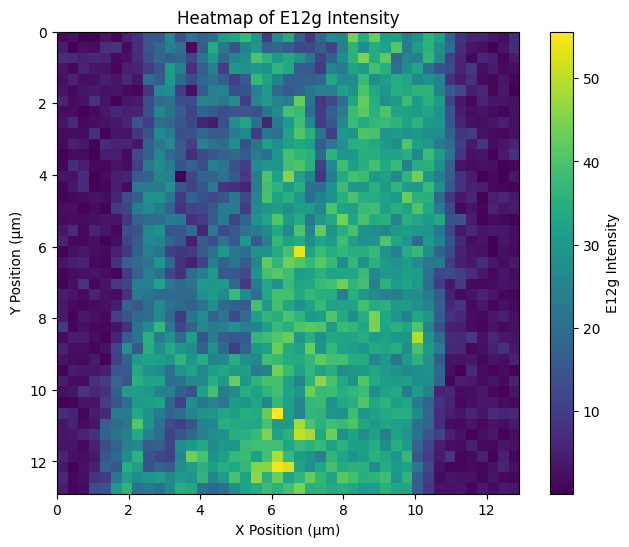

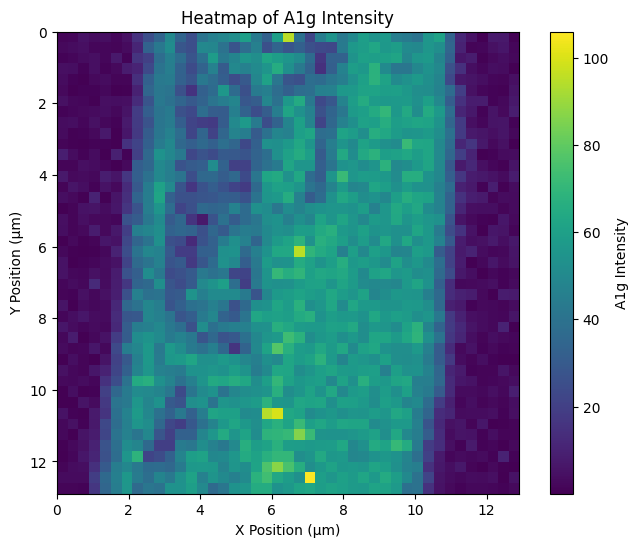

In [3]:
# Heatmaps (peak names must match mapping keys, which match RamanFit peak_labels)
rm_pipe.plot_heatmap(peak_name="E12g", data_type='intensity')
rm_pipe.plot_heatmap(peak_name="A1g", data_type='intensity')